In [ ]:
!pip install -q tensorflow

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
# Upload CIFAR-10 Dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

print(f"Dimensiones de las imágenes de entrenamiento: {train_images.shape}")
print(f"Dimensiones de las etiquetas de entrenamiento: {train_labels.shape}")
print(f"Dimensiones de las imágenes de prueba: {test_images.shape}")
print(f"Dimensiones de las etiquetas de prueba: {test_labels.shape}")

Dimensiones de las imágenes de entrenamiento: (50000, 32, 32, 3)
Dimensiones de las etiquetas de entrenamiento: (50000, 1)
Dimensiones de las imágenes de prueba: (10000, 32, 32, 3)
Dimensiones de las etiquetas de prueba: (10000, 1)


In [ ]:
def pad_image(image, final_size=128):
    """Embeds an image in the center of a zero-padded array."""
    h, w = image.shape
    pad_h = (final_size - h) // 2
    pad_w = (final_size - w) // 2
    # Pad evenly on all sides
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    return padded

def normalize(array):
    """Normalizes an array to be strictly between 0 and 1."""
    return (array - np.min(array)) / (np.max(array) - np.min(array))

In [ ]:
import numpy as np

def precompute_ot_mach_stats(target_images, background_images):
    """
    Precomputes the dataset statistics ONCE before gradient descent.

    - target_images: array of images for the class you want to detect (e.g., cars).
    - background_images: array of images from other classes to model clutter.
    """
    N_target = target_images.shape[0]
    N_bg = background_images.shape[0]

    # Transform targets
    target_spectra = np.array([np.fft.fftshift(np.fft.fft2(img)) for img in target_images])

    # Transform backgrounds
    bg_spectra = np.array([np.fft.fftshift(np.fft.fft2(img)) for img in background_images])

    # Calculate target statistics
    m_x = np.mean(target_spectra, axis=0)
    D_x = np.mean(np.abs(target_spectra)**2, axis=0)
    S_x = np.mean(np.abs(target_spectra - m_x)**2, axis=0)

    # Calculate Colored Noise Matrix (C) from backgrounds
    C = np.mean(np.abs(bg_spectra)**2, axis=0)

    return m_x, D_x, S_x, C

def synthesize_filter_fast(alpha, beta, gamma, m_x, D_x, S_x, C):
    """
    Lightweight function to be called inside your gradient descent loop.
    """
    total = alpha + beta + gamma
    a, b, g = alpha/total, beta/total, gamma/total

    denominator = (a * C) + (b * D_x) + (g * S_x)
    epsilon = 1e-10

    H_filter = np.conj(m_x) / (denominator + epsilon)

    return H_filter

In [ ]:
def ot_mach_optical_correlator(input_img, ot_mach_filter, apply_iris=False, r_in=2, r_out=35, mask_type='bandpass'):
    """
    Simulates a 4f optical correlator using a pre-calculated OT-MACH filter.
    """
    # Ensure float precision
    input_img = np.asarray(input_img, dtype=float)

    # LENS 1: Fourier Plane (Transform input image)
    U_in_focal = np.fft.fftshift(np.fft.fft2(input_img))

    # Apply the OT-MACH filter mask
    H_filter = ot_mach_filter.copy()

    # IRIS (Physical spatial filter)
    if apply_iris:
        h, w = U_in_focal.shape
        iris_mask = create_circular_mask(h, w, r_in=r_in, r_out=r_out, mask_type=mask_type)
        H_filter = H_filter * iris_mask

    # LENS 2: Inverse Transform (Multiply and return to spatial domain)
    U_filtered = U_in_focal * H_filter

    # Calculate the correlation plane intensity
    U_out = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(U_filtered)))
    correlation_plane = np.abs(U_out)**2

    return correlation_plane

In [ ]:

# Turn into grayscale the dataset's images (using tensorflow) and cast to float32 to normalize
train_images_gray = tf.cast(tf.image.rgb_to_grayscale(train_images), tf.float32)
test_images_gray = tf.cast(tf.image.rgb_to_grayscale(test_images), tf.float32)

# Normalize the pixels to a range from 0 to 1
train_images_gray = train_images_gray / 255.0
test_images_gray = test_images_gray / 255.0

print(f"Dimensiones de las imágenes de entrenamiento en escala de grises: {train_images_gray.shape}")
print(f"Dimensiones de las imágenes de prueba en escala de grises: {test_images_gray.shape}")

Dimensiones de las imágenes de entrenamiento en escala de grises: (50000, 32, 32, 1)
Dimensiones de las imágenes de prueba en escala de grises: (10000, 32, 32, 1)


In [ ]:
# Define the classes we want to keep
selected_classes = [0, 1, 8, 9]

# --- Filter the training dataset ---
# Create a boolean mask to select the desired labels
# np.isin() checks if each element of train_labels is present in selected_classes
train_mask = np.isin(train_labels.flatten(), selected_classes)

# Apply the mask to the training images and labels
train_images_filtered = train_images_gray[train_mask]
train_labels_filtered = train_labels[train_mask]

# --- Filter the test dataset ---
# Create a boolean mask to select the desired labels
test_mask = np.isin(test_labels.flatten(), selected_classes)

# Apply the mask to the test images and labels
test_images_filtered = test_images_gray[test_mask]
test_labels_filtered = test_labels[test_mask]

print(f"Dimensiones de las imágenes de entrenamiento filtradas: {train_images_filtered.shape}")
print(f"Dimensiones de las etiquetas de entrenamiento filtradas: {train_labels_filtered.shape}")
print(f"Dimensiones de las imágenes de prueba filtradas: {test_images_filtered.shape}")
print(f"Dimensiones de las etiquetas de prueba filtradas: {test_labels_filtered.shape}")

Dimensiones de las imágenes de entrenamiento filtradas: (20000, 32, 32, 1)
Dimensiones de las etiquetas de entrenamiento filtradas: (20000, 1)
Dimensiones de las imágenes de prueba filtradas: (4000, 32, 32, 1)
Dimensiones de las etiquetas de prueba filtradas: (4000, 1)


In [ ]:
# Remove the channel dimension (the last '1') from the filtered training and test images
train_images_2d = tf.squeeze(train_images_filtered, axis=-1)
test_images_2d = tf.squeeze(test_images_filtered, axis=-1)

print(f"Dimensiones de las imágenes de entrenamiento 2D: {train_images_2d.shape}")
print(f"Dimensiones de las imágenes de prueba 2D: {test_images_2d.shape}")

Dimensiones de las imágenes de entrenamiento 2D: (20000, 32, 32)
Dimensiones de las imágenes de prueba 2D: (4000, 32, 32)


Exploring the dataset

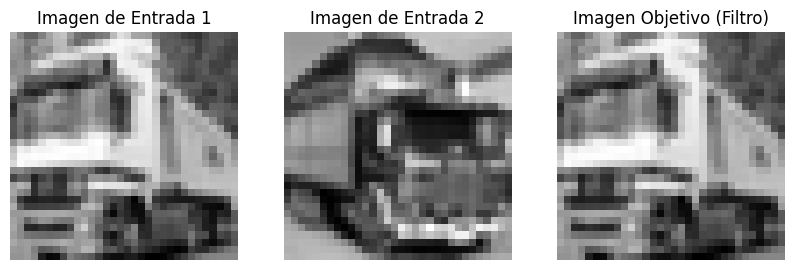

In [ ]:
# Select sample images from the filtered dataset and ensure they are 2D
input_example = train_images_filtered[0, :, :, 0]   # First training image
input_example_2 = train_images_filtered[5, :, :, 0] # Second training image
target_example = train_images_filtered[0, :, :, 0]  # Target image for the filter

# Display the input and target images
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow((input_example), cmap='gray')
plt.title('Imagen de Entrada 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow((input_example_2), cmap='gray')
plt.title('Imagen de Entrada 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow((target_example), cmap='gray')
plt.title('Imagen Objetivo (Filtro)')
plt.axis('off')
plt.show()

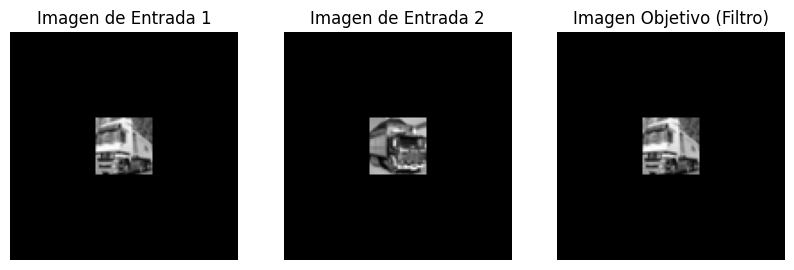

In [ ]:
# Select sample images from the filtered dataset and ensure they are 2D
input_example = train_images_filtered[0, :, :, 0]   # First training image
input_example_2 = train_images_filtered[5, :, :, 0] # Second training image
target_example = train_images_filtered[0, :, :, 0]  # Target image for the filter

# Display the padded input and target images
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(pad_image(input_example), cmap='gray')
plt.title('Imagen de Entrada 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(pad_image(input_example_2), cmap='gray')
plt.title('Imagen de Entrada 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(pad_image(target_example), cmap='gray')
plt.title('Imagen Objetivo (Filtro)')
plt.axis('off')
plt.show()

## <center> **NASA OT-MACH Implementation** </center>

The following code is without the restriction of only use vehicles (truck, ship, airplane and cars)

Loading CIFAR-10 (Airplanes, Ships, Trucks)...
Train: 15000 | Test: 3000

Computing per-class OT-MACH matrices (C, D_x, S_x)...
  Airplane: 500 training FFTs computed
  Ship: 500 training FFTs computed
  Truck: 500 training FFTs computed

--- Per-Class Gradient Descent Optimization ---

Optimizing: Airplane
  Step 5: α=0.198 β=0.271 γ=0.531 score=24.74
  Step 10: α=0.010 β=0.327 γ=0.663 score=25.03
  Step 15: α=0.010 β=0.334 γ=0.656 score=25.03
  Best: α=0.010 β=0.333 γ=0.657

Optimizing: Ship
  Step 5: α=0.128 β=0.755 γ=0.117 score=81.61
  Step 10: α=0.009 β=0.982 γ=0.009 score=90.57
  Step 15: α=0.527 β=0.007 γ=0.465 score=75.59
  Best: α=0.128 β=0.755 γ=0.117

Optimizing: Truck
  Step 5: α=0.195 β=0.793 γ=0.012 score=60.33
  Step 10: α=0.084 β=0.809 γ=0.106 score=60.37
  Step 15: α=0.049 β=0.879 γ=0.072 score=60.32
  Best: α=0.170 β=0.731 γ=0.099

--- Building Diverse Filter Banks ---
  Airplane: 16 filters (1 mean + 15 diverse)
  Ship: 16 filters (1 mean + 15 diverse)
  Truck: 16 f

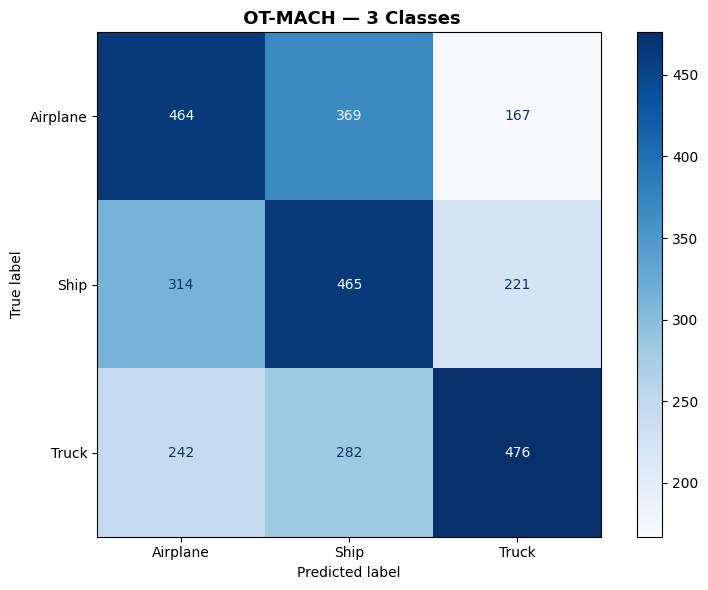

In [ ]:

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import gc
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import MiniBatchKMeans

# Load and prepare data
print("Loading CIFAR-10 (Airplanes, Ships, Trucks)...")
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

train_images_gray = tf.squeeze(
    tf.cast(tf.image.rgb_to_grayscale(train_images), tf.float32) / 255.0
).numpy()
test_images_gray = tf.squeeze(
    tf.cast(tf.image.rgb_to_grayscale(test_images), tf.float32) / 255.0
).numpy()

train_labels_flat = train_labels.flatten()
test_labels_flat = test_labels.flatten()

classes = {0: 'Airplane', 8: 'Ship', 9: 'Truck'}
valid_classes = list(classes.keys())

train_mask = np.isin(train_labels_flat, valid_classes)
test_mask = np.isin(test_labels_flat, valid_classes)

X_train_raw = train_images_gray[train_mask]
y_train = train_labels_flat[train_mask]

X_test_raw = test_images_gray[test_mask]
y_test = test_labels_flat[test_mask]

del train_images, test_images, train_images_gray, test_images_gray
gc.collect()

print(f"Train: {len(X_train_raw)} | Test: {len(X_test_raw)}")

# Preprocessing padding

PAD = 48  # pad 32x32 → 128x128
IMG_SIZE = 32 + 2 * PAD  # = 128

def normalize_img(img):
    """Zero-mean, unit-variance per image."""
    img = img - np.mean(img)
    s = np.std(img)
    return img / s if s > 0 else img

def pad_and_fft_single(img):
    """Normalize, pad, FFT, shift — for a single image."""
    img_n = normalize_img(img)
    padded = np.pad(img_n, ((PAD, PAD), (PAD, PAD)), mode='constant')
    return np.fft.fftshift(np.fft.fft2(padded))

def pad_and_fft_batch(imgs):
    """Batch version."""
    return np.array([pad_and_fft_single(img) for img in imgs], dtype=np.complex128)

# 3. Build per-class matrices

print("\nComputing per-class OT-MACH matrices (C, D_x, S_x)...")

#  Global average power spectrum (noise model)
# Use ALL training images from our 3 classes
N_FOR_C = min(3000, len(X_train_raw))
rng = np.random.default_rng(42)
c_idx = rng.choice(len(X_train_raw), N_FOR_C, replace=False)
c_ffts = pad_and_fft_batch(X_train_raw[c_idx])
C_global = np.mean(np.abs(c_ffts) ** 2, axis=0)  # average power spectrum
del c_ffts
gc.collect()

# Bandpass mask
rows, cols = IMG_SIZE, IMG_SIZE
Y_grid, X_grid = np.ogrid[:rows, :cols]
center = (rows // 2, cols // 2)
radius = np.sqrt((X_grid - center[1])**2 + (Y_grid - center[0])**2)
bandpass_mask = ((radius >= 2) & (radius <= 50)).astype(float)

# Per-class: m_x (mean FFT), D_x (power of mean), S_x (intra-class variance)
N_TRAIN_PER_CLASS = 500  # Use many training images per class for better statistics

class_data = {}
for cls in valid_classes:
    idx = np.where(y_train == cls)[0]
    sel = rng.choice(idx, min(N_TRAIN_PER_CLASS, len(idx)), replace=False)
    ffts = pad_and_fft_batch(X_train_raw[sel])

    # m_x: Mean Fourier transform of the class (complex-valued)
    m_x = np.mean(ffts, axis=0)

    # D_x: |m_x|^2 — power spectrum of the class mean
    D_x = np.abs(m_x) ** 2

    # S_x: Intra class variance = mean(|X_i - m_x|^2)
    # This measures how much individual class members deviate from the mean
    S_x = np.mean(np.abs(ffts - m_x[np.newaxis, :, :]) ** 2, axis=0)

    class_data[cls] = {
        'm_x': m_x,
        'D_x': D_x,
        'S_x': S_x,
        'ffts': ffts,  # keep for filter bank building
    }
    print(f"  {classes[cls]}: {len(sel)} training FFTs computed")

# 4. OT-MACH Filter Builder

def build_otmach_filter(m_x, D_x, S_x, C, a, b, g, mask):
    """
    OT-MACH filter per Kumar et al. 1994:

        H(u,v) = conj(m_x) / [α·C + β·D_x + γ·S_x]

    Where:
        m_x  = mean Fourier transform of the target class
        C    = average power spectrum (all classes — noise/clutter model)
        D_x  = |m_x|^2  (power of the class mean — distortion tolerance)
        S_x  = intra-class variance (similarity measure)
        α    = weight for noise tolerance (ONV)
        β    = weight for correlation energy suppression (ACE)
        γ    = weight for intra-class similarity (ASM)
    """
    denom = a * C + b * D_x + g * S_x + 1e-10
    H = np.conj(m_x) / denom
    H = H * mask
    # L2 normalize
    energy = np.sqrt(np.sum(np.abs(H) ** 2))
    if energy > 0:
        H = H / energy
    return H


def correlate_and_score(H_filter, img_fft):
    """Apply filter in Fourier plane, inverse transform, return correlation plane intensity."""
    U_filtered = img_fft * H_filter
    u_out = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(U_filtered)))
    return np.abs(u_out) ** 2


def calculate_psr(plane, peak_radius=5):
    """
    PSR with peak exclusion window (correct formulation).
    Excludes a small neighborhood around the peak so the peak
    doesn't inflate the sidelobe statistics.
    """
    peak_val = np.max(plane)
    py, px = np.unravel_index(np.argmax(plane), plane.shape)

    # Create mask excluding peak neighborhood
    yy, xx = np.ogrid[:plane.shape[0], :plane.shape[1]]
    peak_mask = ((yy - py)**2 + (xx - px)**2) > peak_radius**2
    sidelobes = plane[peak_mask]

    mean_sl = np.mean(sidelobes)
    std_sl = np.std(sidelobes)

    return (peak_val - mean_sl) / (std_sl + 1e-10)


# 5. Gradient Descent Optimization
print("\n--- Per-Class Gradient Descent Optimization ---")

def evaluate_filter_quality(H, target_ffts, clutter_ffts, n_eval=50):
    """
    Composite score per the paper: optimize BOTH peak height and PSR.
    Score = mean_target_PSR - mean_clutter_PSR
    This directly optimizes discrimination (sharp peaks on targets,
    flat response on clutter).
    """
    target_psrs = []
    for fft in target_ffts[:n_eval]:
        plane = correlate_and_score(H, fft)
        target_psrs.append(calculate_psr(plane))

    clutter_psrs = []
    for fft in clutter_ffts[:n_eval]:
        plane = correlate_and_score(H, fft)
        clutter_psrs.append(calculate_psr(plane))

    # The paper combines PK and PSR. We use PSR as the unified metric
    # since it inherently captures both peak height and sidelobe suppression.
    return np.mean(target_psrs) - 0.5 * np.mean(clutter_psrs)


optimized_params = {}

for cls in valid_classes:
    print(f"\nOptimizing: {classes[cls]}")

    # Target = this class, Clutter = other classes
    target_ffts = class_data[cls]['ffts']
    clutter_idx = np.where(y_train != cls)[0]
    clutter_sel = rng.choice(clutter_idx, 100, replace=False)
    clutter_ffts = pad_and_fft_batch(X_train_raw[clutter_sel])

    m_x = class_data[cls]['m_x']
    D_x = class_data[cls]['D_x']
    S_x = class_data[cls]['S_x']

    # Initialize
    a, b, g = 0.4, 0.3, 0.3
    best_score = -np.inf
    best_params = (a, b, g)

    GD_STEPS = 15
    lr = 0.05
    eps = 0.02

    for step in range(1, GD_STEPS + 1):
        H_current = build_otmach_filter(m_x, D_x, S_x, C_global, a, b, g, bandpass_mask)
        score = evaluate_filter_quality(H_current, target_ffts, clutter_ffts, n_eval=40)

        if score > best_score:
            best_score = score
            best_params = (a, b, g)

        # Numerical gradients
        H_a = build_otmach_filter(m_x, D_x, S_x, C_global, a + eps, b, g, bandpass_mask)
        H_b = build_otmach_filter(m_x, D_x, S_x, C_global, a, b + eps, g, bandpass_mask)
        H_g = build_otmach_filter(m_x, D_x, S_x, C_global, a, b, g + eps, bandpass_mask)

        score_a = evaluate_filter_quality(H_a, target_ffts, clutter_ffts, n_eval=40)
        score_b = evaluate_filter_quality(H_b, target_ffts, clutter_ffts, n_eval=40)
        score_g = evaluate_filter_quality(H_g, target_ffts, clutter_ffts, n_eval=40)

        grad_a = (score_a - score) / eps
        grad_b = (score_b - score) / eps
        grad_g = (score_g - score) / eps

        a += lr * grad_a
        b += lr * grad_b
        g += lr * grad_g

        # Clamp to positive and normalize
        a, b, g = max(a, 0.01), max(b, 0.01), max(g, 0.01)
        total = a + b + g
        a, b, g = a / total, b / total, g / total

        if step % 5 == 0:
            print(f"  Step {step}: α={a:.3f} β={b:.3f} γ={g:.3f} score={score:.2f}")

    optimized_params[cls] = best_params
    print(f"  Best: α={best_params[0]:.3f} β={best_params[1]:.3f} γ={best_params[2]:.3f}")

    del clutter_ffts
    gc.collect()

# 6. Build diverse filter bank
print("\n--- Building Diverse Filter Banks ---")

TEMPLATES_PER_CLASS = 15
filter_bank = {}

for cls in valid_classes:
    a, b, g = optimized_params[cls]
    ffts = class_data[cls]['ffts']

    # Use K-Means on the magnitude spectra to find diverse templates
    # This ensures the filter bank covers the full intra-class variation
    mag_features = np.abs(ffts).reshape(len(ffts), -1)
    n_clusters = min(TEMPLATES_PER_CLASS, len(ffts))
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, n_init=3)
    kmeans.fit(mag_features)

    # Pick the image closest to each cluster center
    filters = []
    for k in range(n_clusters):
        cluster_members = np.where(kmeans.labels_ == k)[0]
        center = kmeans.cluster_centers_[k]
        dists = np.linalg.norm(mag_features[cluster_members] - center, axis=1)
        representative = cluster_members[np.argmin(dists)]

        # Build OT-MACH filter using this representative as m_x
        # but with the CLASS-LEVEL D_x and S_x (not per-image)
        H = build_otmach_filter(
            ffts[representative],            # representative template
            class_data[cls]['D_x'],           # class-level D_x
            class_data[cls]['S_x'],           # class-level S_x
            C_global, a, b, g, bandpass_mask
        )
        filters.append(H)

    # Also add the class-mean filter (most important one)
    H_mean = build_otmach_filter(
        class_data[cls]['m_x'],
        class_data[cls]['D_x'],
        class_data[cls]['S_x'],
        C_global, a, b, g, bandpass_mask
    )
    filters.insert(0, H_mean)  # Mean filter first

    filter_bank[cls] = filters
    print(f"  {classes[cls]}: {len(filters)} filters (1 mean + {n_clusters} diverse)")

# Free memory
for cls in valid_classes:
    del class_data[cls]['ffts']
gc.collect()

# Evaluation
print(f"\nEvaluating {len(X_test_raw)} test images...")

y_pred = []
for i in range(len(X_test_raw)):
    img_fft = pad_and_fft_single(X_test_raw[i])

    class_scores = {}
    for cls in valid_classes:
        best_psr = -np.inf
        for H_filter in filter_bank[cls]:
            plane = correlate_and_score(H_filter, img_fft)
            psr = calculate_psr(plane, peak_radius=5)
            if psr > best_psr:
                best_psr = psr
        class_scores[cls] = best_psr

    predicted_class = max(class_scores, key=class_scores.get)
    y_pred.append(predicted_class)

    if (i + 1) % 500 == 0:
        print(f"  Processed {i + 1} / {len(X_test_raw)} images...")

# Metrics computation
print("\n" + "=" * 60)
print(" OT-MACH")
print("=" * 60)

y_pred = np.array(y_pred)
target_names = [classes[c] for c in valid_classes]
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=valid_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title(" OT-MACH — 3 Classes",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Loading CIFAR-10 (Airplanes, Cars, Ships, Trucks)...
Train: 20000 | Test: 4000

Computing per-class OT-MACH matrices (C, D_x, S_x)...
  Airplane: 500 training FFTs computed
  Car: 500 training FFTs computed
  Ship: 500 training FFTs computed
  Truck: 500 training FFTs computed

--- Per-Class Gradient Descent Optimization ---

Optimizing: Airplane
  Step 5: α=0.215 β=0.365 γ=0.420 score=32.52
  Step 10: α=0.010 β=0.566 γ=0.424 score=32.94
  Step 15: α=0.010 β=0.728 γ=0.262 score=33.17
  Best: α=0.010 β=0.719 γ=0.270

Optimizing: Car
  Step 5: α=0.434 β=0.440 γ=0.126 score=27.02
  Step 10: α=0.499 β=0.488 γ=0.013 score=27.10
  Step 15: α=0.463 β=0.527 γ=0.010 score=27.12
  Best: α=0.470 β=0.520 γ=0.010

Optimizing: Ship
  Step 5: α=0.322 β=0.395 γ=0.283 score=73.87
  Step 10: α=0.012 β=0.827 γ=0.161 score=72.81
  Step 15: α=0.382 β=0.274 γ=0.344 score=70.06
  Best: α=0.031 β=0.782 γ=0.187

Optimizing: Truck
  Step 5: α=0.032 β=0.955 γ=0.013 score=85.43
  Step 10: α=0.275 β=0.714 γ=0.011 

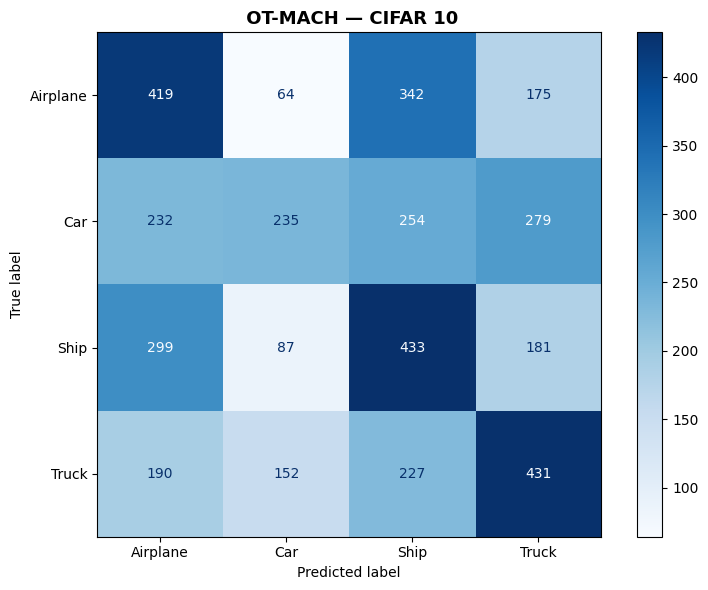

In [ ]:
"""
OT-MACH Filter — Corrected Implementation for CIFAR-10 4-Class Classification
==============================================================================

Based on: "Optimization of OT-MACH filter generation for target recognition"
  Johnson, Edens, Lu, Chao — JPL/CalTech, SPIE Vol. 7340, 2009

And the foundational OT-MACH theory from:
  Kumar, Carlson, Mahalanobis — "Optimal Trade-Off Synthetic Discriminant
  Function Filters for Arbitrary Devices," Opt. Lett. 19, 1994.
"""

# FIX: Added Class 1 (Automobile/Car) to the dictionary
classes = {0: 'Airplane', 1: 'Car', 8: 'Ship', 9: 'Truck'}
valid_classes = list(classes.keys())

train_mask = np.isin(train_labels_flat, valid_classes)
test_mask = np.isin(test_labels_flat, valid_classes)

X_train_raw = train_images_gray[train_mask]
y_train = train_labels_flat[train_mask]

X_test_raw = test_images_gray[test_mask]
y_test = test_labels_flat[test_mask]

del train_images, test_images, train_images_gray, test_images_gray
gc.collect()

print(f"Train: {len(X_train_raw)} | Test: {len(X_test_raw)}")

# Preprocessing helpers

PAD = 48  # pad 32x32 → 128x128
IMG_SIZE = 32 + 2 * PAD  # = 128

def normalize_img(img):
    """Zero-mean, unit-variance per image."""
    img = img - np.mean(img)
    s = np.std(img)
    return img / s if s > 0 else img

def pad_and_fft_single(img):
    """Normalize, pad, FFT, shift — for a single image."""
    img_n = normalize_img(img)
    padded = np.pad(img_n, ((PAD, PAD), (PAD, PAD)), mode='constant')
    return np.fft.fftshift(np.fft.fft2(padded))

def pad_and_fft_batch(imgs):
    """Batch version."""
    return np.array([pad_and_fft_single(img) for img in imgs], dtype=np.complex128)

# Build per-class matrices

print("\nComputing per-class OT-MACH matrices (C, D_x, S_x)...")

#  Global average power spectrum
N_FOR_C = min(3000, len(X_train_raw))
rng = np.random.default_rng(42)
c_idx = rng.choice(len(X_train_raw), N_FOR_C, replace=False)
c_ffts = pad_and_fft_batch(X_train_raw[c_idx])
C_global = np.mean(np.abs(c_ffts) ** 2, axis=0)
del c_ffts
gc.collect()

# Bandpass mask
rows, cols = IMG_SIZE, IMG_SIZE
Y_grid, X_grid = np.ogrid[:rows, :cols]
center = (rows // 2, cols // 2)
radius = np.sqrt((X_grid - center[1])**2 + (Y_grid - center[0])**2)
bandpass_mask = ((radius >= 2) & (radius <= 50)).astype(float)

# --- Per-class: m_x, D_x, S_x ---
N_TRAIN_PER_CLASS = 500

class_data = {}
for cls in valid_classes:
    idx = np.where(y_train == cls)[0]
    sel = rng.choice(idx, min(N_TRAIN_PER_CLASS, len(idx)), replace=False)
    ffts = pad_and_fft_batch(X_train_raw[sel])

    m_x = np.mean(ffts, axis=0)
    D_x = np.abs(m_x) ** 2
    S_x = np.mean(np.abs(ffts - m_x[np.newaxis, :, :]) ** 2, axis=0)

    class_data[cls] = {
        'm_x': m_x,
        'D_x': D_x,
        'S_x': S_x,
        'ffts': ffts,
    }
    print(f"  {classes[cls]}: {len(sel)} training FFTs computed")

# OT-MACH Filter
def build_otmach_filter(m_x, D_x, S_x, C, a, b, g, mask):
    denom = a * C + b * D_x + g * S_x + 1e-10
    H = np.conj(m_x) / denom
    H = H * mask
    energy = np.sqrt(np.sum(np.abs(H) ** 2))
    if energy > 0:
        H = H / energy
    return H

def correlate_and_score(H_filter, img_fft):
    U_filtered = img_fft * H_filter
    u_out = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(U_filtered)))
    return np.abs(u_out) ** 2

def calculate_psr(plane, peak_radius=5):
    peak_val = np.max(plane)
    py, px = np.unravel_index(np.argmax(plane), plane.shape)

    yy, xx = np.ogrid[:plane.shape[0], :plane.shape[1]]
    peak_mask = ((yy - py)**2 + (xx - px)**2) > peak_radius**2
    sidelobes = plane[peak_mask]

    mean_sl = np.mean(sidelobes)
    std_sl = np.std(sidelobes)

    return (peak_val - mean_sl) / (std_sl + 1e-10)

# 5. Gradient Descent Optimization

print("\n Per-Class Gradient Descent Optimization")

def evaluate_filter_quality(H, target_ffts, clutter_ffts, n_eval=50):
    target_psrs = []
    for fft in target_ffts[:n_eval]:
        plane = correlate_and_score(H, fft)
        target_psrs.append(calculate_psr(plane))

    clutter_psrs = []
    for fft in clutter_ffts[:n_eval]:
        plane = correlate_and_score(H, fft)
        clutter_psrs.append(calculate_psr(plane))

    return np.mean(target_psrs) - 0.5 * np.mean(clutter_psrs)

optimized_params = {}

for cls in valid_classes:
    print(f"\nOptimizing: {classes[cls]}")

    target_ffts = class_data[cls]['ffts']
    clutter_idx = np.where(y_train != cls)[0]
    clutter_sel = rng.choice(clutter_idx, 100, replace=False)
    clutter_ffts = pad_and_fft_batch(X_train_raw[clutter_sel])

    m_x = class_data[cls]['m_x']
    D_x = class_data[cls]['D_x']
    S_x = class_data[cls]['S_x']

    a, b, g = 0.4, 0.3, 0.3
    best_score = -np.inf
    best_params = (a, b, g)

    GD_STEPS = 15
    lr = 0.05
    eps = 0.02

    for step in range(1, GD_STEPS + 1):
        H_current = build_otmach_filter(m_x, D_x, S_x, C_global, a, b, g, bandpass_mask)
        score = evaluate_filter_quality(H_current, target_ffts, clutter_ffts, n_eval=40)

        if score > best_score:
            best_score = score
            best_params = (a, b, g)

        H_a = build_otmach_filter(m_x, D_x, S_x, C_global, a + eps, b, g, bandpass_mask)
        H_b = build_otmach_filter(m_x, D_x, S_x, C_global, a, b + eps, g, bandpass_mask)
        H_g = build_otmach_filter(m_x, D_x, S_x, C_global, a, b, g + eps, bandpass_mask)

        score_a = evaluate_filter_quality(H_a, target_ffts, clutter_ffts, n_eval=40)
        score_b = evaluate_filter_quality(H_b, target_ffts, clutter_ffts, n_eval=40)
        score_g = evaluate_filter_quality(H_g, target_ffts, clutter_ffts, n_eval=40)

        grad_a = (score_a - score) / eps
        grad_b = (score_b - score) / eps
        grad_g = (score_g - score) / eps

        a += lr * grad_a
        b += lr * grad_b
        g += lr * grad_g

        a, b, g = max(a, 0.01), max(b, 0.01), max(g, 0.01)
        total = a + b + g
        a, b, g = a / total, b / total, g / total

        if step % 5 == 0:
            print(f"  Step {step}: α={a:.3f} β={b:.3f} γ={g:.3f} score={score:.2f}")

    optimized_params[cls] = best_params
    print(f"  Best: α={best_params[0]:.3f} β={best_params[1]:.3f} γ={best_params[2]:.3f}")

    del clutter_ffts
    gc.collect()

# 6. Build Diverse Filter Bank
print("\n--- Building Diverse Filter Banks ---")

TEMPLATES_PER_CLASS = 15
filter_bank = {}

for cls in valid_classes:
    a, b, g = optimized_params[cls]
    ffts = class_data[cls]['ffts']

    mag_features = np.abs(ffts).reshape(len(ffts), -1)
    n_clusters = min(TEMPLATES_PER_CLASS, len(ffts))
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, n_init=3)
    kmeans.fit(mag_features)

    filters = []
    for k in range(n_clusters):
        cluster_members = np.where(kmeans.labels_ == k)[0]
        center = kmeans.cluster_centers_[k]
        dists = np.linalg.norm(mag_features[cluster_members] - center, axis=1)
        representative = cluster_members[np.argmin(dists)]

        H = build_otmach_filter(
            ffts[representative],
            class_data[cls]['D_x'],
            class_data[cls]['S_x'],
            C_global, a, b, g, bandpass_mask
        )
        filters.append(H)

    H_mean = build_otmach_filter(
        class_data[cls]['m_x'],
        class_data[cls]['D_x'],
        class_data[cls]['S_x'],
        C_global, a, b, g, bandpass_mask
    )
    filters.insert(0, H_mean)

    filter_bank[cls] = filters
    print(f"  {classes[cls]}: {len(filters)} filters (1 mean + {n_clusters} diverse)")

for cls in valid_classes:
    del class_data[cls]['ffts']
gc.collect()

# Evaluation
print(f"\nEvaluating {len(X_test_raw)} test images...")

y_pred = []
for i in range(len(X_test_raw)):
    img_fft = pad_and_fft_single(X_test_raw[i])

    class_scores = {}
    for cls in valid_classes:
        best_psr = -np.inf
        for H_filter in filter_bank[cls]:
            plane = correlate_and_score(H_filter, img_fft)
            psr = calculate_psr(plane, peak_radius=5)
            if psr > best_psr:
                best_psr = psr
        class_scores[cls] = best_psr

    predicted_class = max(class_scores, key=class_scores.get)
    y_pred.append(predicted_class)

    if (i + 1) % 500 == 0:
        print(f"  Processed {i + 1} / {len(X_test_raw)} images...")

# Metrics computation
print("\n" + "=" * 60)
print("  CORRECTED OT-MACH — 4-CLASS CLASSIFICATION REPORT")
print("=" * 60)

y_pred = np.array(y_pred)
target_names = [classes[c] for c in valid_classes]
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=valid_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title(" OT-MACH — CIFAR 10",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
